# sequence learning.
## We’ll use an LSTM neural network (deep learning model made for time sequences).
Instead of predicting directly from one day’s values, we’ll train the model like:

“Use the last 30 days’ Open, High, Low, Close, Volume data → predict next day Close.”

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# Load data
df = pd.read_csv("../data/Crypto_historical_data.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

# Keep numeric columns only
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df[features].values


In [2]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


In [3]:
SEQ_LEN = 30  # Use past 30 days

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, 3])  # 3 = index of 'Close' in features
    return np.array(X), np.array(y)

X, y = make_sequences(scaled_data, SEQ_LEN)


In [4]:
split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]


In [5]:
model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 128)             │          68,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=32,
    verbose=1
)


Epoch 1/2
8558/8558 ━━━━━━━━━━━━━━━━━━━━ 202s 23ms/step - loss: 0.4080 - mae: 0.2027 - val_loss: 3.3756 - val_mae: 0.4535
Epoch 2/2
8558/8558 ━━━━━━━━━━━━━━━━━━━━ 198s 23ms/step - loss: 0.4080 - mae: 0.2025 - val_loss: 3.3852 - val_mae: 0.4411


# Test the mode

In [10]:
import numpy as np

# Ensure correct shapes
y_pred = np.array(y_pred).reshape(-1, 1)
y_val = np.array(y_val).reshape(-1, 1)

# Inverse transform (scaler must be same one fitted on y_train)
y_pred_inv = inverse_transform_target(scaler, y_pred)
y_val_inv = inverse_transform_target(scaler, y_val)


# Flatten for plotting
y_pred_inv = y_pred_inv.flatten()
y_val_inv = y_val_inv.flatten()

# Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_val_inv, label='Actual', color='blue', linewidth=2)
plt.plot(y_pred_inv, label='Predicted', color='orange', linewidth=2)
plt.legend()
plt.show()


NameError: name 'y_pred' is not defined

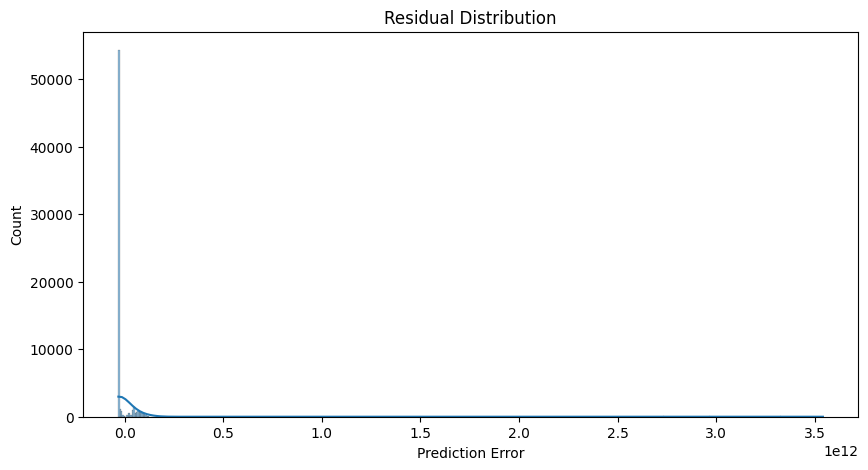

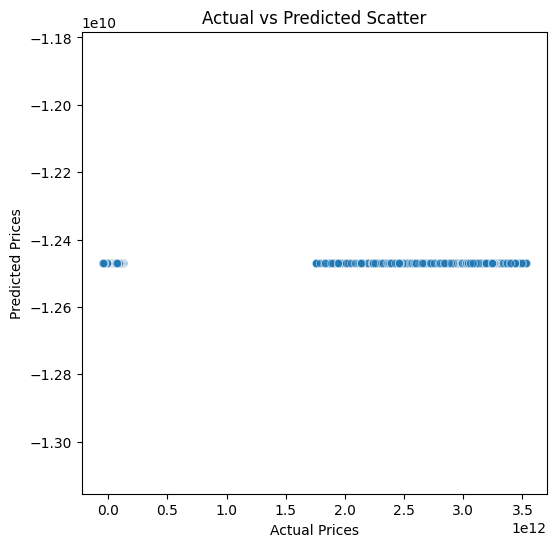

In [16]:
import seaborn as sns
import numpy as np

# Residuals (errors)
residuals = y_val_inv - y_pred_inv

# Plot residual distribution
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

# Scatter plot of actual vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val_inv.flatten(), y=y_pred_inv.flatten(), alpha=0.6)
plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()
